# 1. Import Libraries

In [50]:
import os
import sys
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 2. File Paths

In [31]:
scripts_path = os.path.abspath(os.path.join('..', 'Scripts'))
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

data_dir = os.path.abspath(os.path.join('..', 'Data', 'TrainTest'))
hyperparameter_dir = os.path.abspath(os.path.join('..', 'Data', 'HyperParameters'))
save_dir = os.path.abspath(os.path.join('..', 'Data', 'SavedModels'))
loss_history_dir = os.path.abspath(os.path.join('..', 'Data','LossHistory'))

# 3. Load Models & Data

## 1. Data

In [32]:
train_data = np.load(os.path.join(data_dir, 'train_data.npy')).astype(np.float32)
num_items = train_data.shape[1]

## 2. Models

In [33]:
from model import Encoder, Decoder, VAE, RSVD

# 4. Training

## 1. VAE

### 1. Import Hyperparameters

In [34]:
vae_progress_file = os.path.join(hyperparameter_dir, 'tuning_progress_vae.json')
with open(vae_progress_file, 'r') as f:
    best_vae_params = json.load(f)['best_params']

print(f"\n[INFO] Melatih ulang VAE dengan parameter terbaik: {best_vae_params}")


[INFO] Melatih ulang VAE dengan parameter terbaik: {'latent_dim': 10, 'learning_rate': 0.005, 'batch_size': 64, 'dropout_rate': 0.5, 'hidden_dims': [512, 256]}


### 2. Construct Model

In [35]:
encoder = Encoder(hidden_dims=best_vae_params['hidden_dims'], latent_dim=best_vae_params['latent_dim'], dropout_rate=best_vae_params['dropout_rate'])
decoder = Decoder(hidden_dims=best_vae_params['hidden_dims'][::-1], output_dim=num_items)
final_vae = VAE(encoder, decoder)

_ = final_vae(train_data[:1]) 
optimizer = tf.keras.optimizers.Adam(learning_rate=best_vae_params['learning_rate'])
final_vae.compile(optimizer=optimizer)

# Fitur Early Stopping: Berhenti jika loss tidak membaik selama 10 epoch berturut-turut
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='loss', patience=10, restore_best_weights=True, verbose=1
)

### 3. Training Model

In [36]:
history = final_vae.fit(
    train_data, train_data, 
    epochs=200,
    batch_size=best_vae_params['batch_size'], 
    callbacks=[early_stopping],
    verbose=1 # Tampilkan progress bar agar kita tahu pergerakannya
)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 13.4727 - loss: 387.8294 - reconstruction_loss: 374.3566  
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - kl_loss: 1.9793 - loss: 209.4818 - reconstruction_loss: 207.5025
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 2.5998 - loss: 195.4773 - reconstruction_loss: 192.8775
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 3.7691 - loss: 187.0598 - reconstruction_loss: 183.2906
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 4.4841 - loss: 183.8953 - reconstruction_loss: 179.4112
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 4.4611 - loss: 180.3673 - reconstruction_loss: 175.9062
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 5.0177 - loss: 177.1722 - reconstruction_loss: 172.1545
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - kl_loss: 5.2862 - loss: 174.7065 - reconstruction_loss: 169.4202
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - 

### 4. Save Weights
    Save model weights after finished training

In [37]:
final_vae.save_weights(os.path.join(save_dir, 'trained_best_vae_weights.weights.h5'))
print("[SUCCESS] Bobot VAE Final berhasil disimpan!")

[SUCCESS] Bobot VAE Final berhasil disimpan!


### 5. Save Loss History
    Save loss history for visualization later

In [38]:
vae_history_dict = {'loss': history.history['loss']}

with open(os.path.join(loss_history_dir, 'final_vae_loss_history.json'), 'w') as f:
    json.dump(vae_history_dict, f)

### 6. Latent Matrix Z
    Get latent matrix from VAE for training RSVD

In [39]:
print("\n[INFO] Mengekstrak Matriks Laten Z Final...")
z_mean, _ = final_vae.encoder.predict(train_data, batch_size=best_vae_params['batch_size'])
latent_matrix_Z_final = z_mean


[INFO] Mengekstrak Matriks Laten Z Final...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


## 2. RSVD

### 1. Import Hyperparameters

In [40]:
rsvd_progress_file = os.path.join(hyperparameter_dir, 'tuning_progress_rsvd.json')
with open(rsvd_progress_file, 'r') as f:
    best_rsvd_params = json.load(f)['best_params']

print(f"\n[INFO] Melatih ulang RSVD dengan parameter terbaik: {best_rsvd_params}")


[INFO] Melatih ulang RSVD dengan parameter terbaik: {'n_factors': 10, 'learning_rate': 0.05, 'lambda_reg': 0.001}


### 2. Construct Model

In [41]:
final_rsvd = RSVD(
    n_factors=best_rsvd_params['n_factors'], 
    learning_rate=best_rsvd_params['learning_rate'], 
    lambda_reg=best_rsvd_params['lambda_reg'], 
    epochs=100 # Naik drastis agar dekomposisi sempurna
)

### 3. Training Model

In [42]:
final_rsvd.fit(latent_matrix_Z_final)

Epoch 001/100 | Training MSE: 0.805757
Epoch 002/100 | Training MSE: 0.799318
Epoch 003/100 | Training MSE: 0.686029
Epoch 004/100 | Training MSE: 0.423929
Epoch 005/100 | Training MSE: 0.279756
Epoch 006/100 | Training MSE: 0.166793
Epoch 007/100 | Training MSE: 0.074267
Epoch 008/100 | Training MSE: 0.050350
Epoch 009/100 | Training MSE: 0.041874
Epoch 010/100 | Training MSE: 0.039416
Epoch 011/100 | Training MSE: 0.038671
Epoch 012/100 | Training MSE: 0.037388
Epoch 013/100 | Training MSE: 0.036338
Epoch 014/100 | Training MSE: 0.036700
Epoch 015/100 | Training MSE: 0.035741
Epoch 016/100 | Training MSE: 0.032805
Epoch 017/100 | Training MSE: 0.029078
Epoch 018/100 | Training MSE: 0.025580
Epoch 019/100 | Training MSE: 0.022606
Epoch 020/100 | Training MSE: 0.020108
Epoch 021/100 | Training MSE: 0.018253
Epoch 022/100 | Training MSE: 0.017099
Epoch 023/100 | Training MSE: 0.016511
Epoch 024/100 | Training MSE: 0.016284
Epoch 025/100 | Training MSE: 0.016193
Epoch 026/100 | Training 

### 4. Save Weights

In [43]:
np.save(os.path.join(save_dir, 'best_U.npy'), final_rsvd.U)
np.save(os.path.join(save_dir, 'best_Sigma.npy'), final_rsvd.Sigma)
np.save(os.path.join(save_dir, 'best_V.npy'), final_rsvd.V)
print("[SUCCESS] Matriks RSVD Final berhasil disimpan!")

[SUCCESS] Matriks RSVD Final berhasil disimpan!


### 5. Save Loss History
    Save loss history for visualization later

In [44]:
np.save(os.path.join(loss_history_dir, 'final_rsvd_loss_history.npy'), final_rsvd.loss_history)

# 5. Training Visualization

## 1. Import Loss History

### 1. VAE

In [45]:
try:
    # Load History Data from Hard Drive
    with open(os.path.join(loss_history_dir, 'final_vae_loss_history.json'), 'r') as f:
        vae_loss_history = json.load(f)['loss']

except FileNotFoundError as e:
    print(f"[ERROR] Could not find the history files. Details: {e}")

### 2. RSVD

In [46]:
rsvd_loss_history = np.load(os.path.join(loss_history_dir, 'final_rsvd_loss_history.npy'))

## 2. Visualization

[SUCCESS] High-resolution plot saved at: c:\Users\USER\Documents\Folder-Proposal\Programs\Data\SavedModels\final_training_curves.png


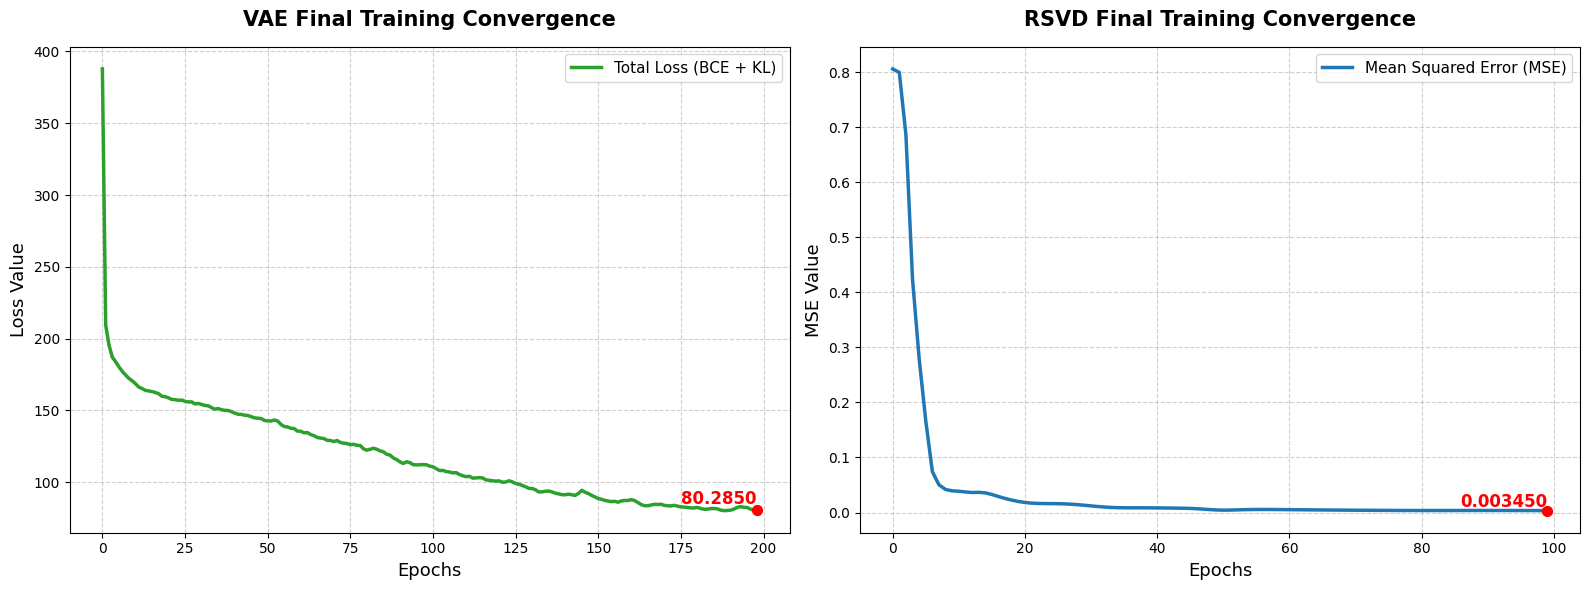

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)
    
# ==========================================
# PLOT 1: VAE LOSS CURVE
# ==========================================
ax1 = axes[0]
ax1.plot(vae_loss_history, label='Total Loss (BCE + KL)', color='#2ca02c', linewidth=2.5)

# Highlight the final epoch
vae_final_epoch = len(vae_loss_history) - 1
vae_final_loss = vae_loss_history[-1]
ax1.scatter(vae_final_epoch, vae_final_loss, color='red', s=50, zorder=5)
ax1.text(vae_final_epoch, vae_final_loss + (vae_final_loss * 0.02), f'{vae_final_loss:.4f}', 
         ha='right', va='bottom', fontsize=12, fontweight='bold', color='red')
         
ax1.set_title('VAE Final Training Convergence', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Epochs', fontsize=13)
ax1.set_ylabel('Loss Value', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right', fontsize=11)
# ==========================================
# PLOT 2: RSVD MSE CURVE
# ==========================================
ax2 = axes[1]
ax2.plot(rsvd_loss_history, label='Mean Squared Error (MSE)', color='#1f77b4', linewidth=2.5)

# Highlight the final epoch
rsvd_final_epoch = len(rsvd_loss_history) - 1
rsvd_final_loss = rsvd_loss_history[-1]
ax2.scatter(rsvd_final_epoch, rsvd_final_loss, color='red', s=50, zorder=5)
ax2.text(rsvd_final_epoch, rsvd_final_loss + (rsvd_final_loss * 0.02), f'{rsvd_final_loss:.6f}', 
         ha='right', va='bottom', fontsize=12, fontweight='bold', color='red')
         
ax2.set_title('RSVD Final Training Convergence', fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel('Epochs', fontsize=13)
ax2.set_ylabel('MSE Value', fontsize=13)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right', fontsize=11)
# ==========================================
# FINALIZE AND DISPLAY
# ==========================================
plt.tight_layout()

# Save the high-resolution image for your thesis report
plot_path = os.path.join(save_dir, 'final_training_curves.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"[SUCCESS] High-resolution plot saved at: {plot_path}")

plt.show()